In [1]:
import pandas as pd
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [5]:
df = pd.read_csv(r"C:\Users\HP\Downloads\ML project\Electronic-Retail-Sales-Analysis-ML\data\cleaned_data.csv")

In [7]:
print("Columns:", df.columns)

Columns: Index(['customer id', 'age', 'gender', 'loyalty member', 'product type', 'sku',
       'rating', 'order status', 'payment method', 'total price', 'unit price',
       'quantity', 'purchase date', 'shipping type', 'add-ons purchased',
       'add-on total', 'month', 'day', 'year', 'sales', 'month_year'],
      dtype='object')


In [9]:
# REGRESSION MODEL (SALES PREDICTION)
# ------------------------------
X = df[['unit price', 'quantity', 'month', 'product type', 'gender']]
y = df['total price']

In [10]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [13]:
print(X_train.dtypes)

unit price      float64
quantity          int64
month             int64
product type     object
gender           object
dtype: object


In [14]:
X_train = pd.get_dummies(X_train, columns=['product type', 'gender'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['product type', 'gender'], drop_first=True)

In [15]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ No error now — scaling successful!")

✅ No error now — scaling successful!


In [17]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
# Predictions
pred = model.predict(X_test)

In [19]:
# Evaluation
print("Regression Results:")
print("MAE:", mean_absolute_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))



Regression Results:
MAE: 668.2830918090625
R2 Score: 0.8747118790000381


In [21]:
# Save model
pickle.dump(model, open(r"C:\Users\HP\Downloads\ML project\Electronic-Retail-Sales-Analysis-ML\notebook\artifacts\sales_model.pkl", "wb"))

# CUSTOMER SEGMENTATION (CLUSTERING)

In [23]:
customer_df = df.groupby('customer id').agg({
    'total price': 'sum',
    'quantity': 'sum'
})

In [25]:
customer_df['frequency'] = df.groupby('customer id').size()

# Rename columns
customer_df.columns = ['total_spending', 'total_quantity', 'frequency']

In [26]:
# SCALING
# ------------------------------
cluster_scaler = StandardScaler()
scaled_data = cluster_scaler.fit_transform(customer_df)

In [27]:
# KMEANS CLUSTERING
# ------------------------------
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_df['cluster'] = kmeans.fit_predict(scaled_data)


In [28]:
# SAVE FILES
# ------------------------------
pickle.dump(kmeans, open(r"C:\Users\HP\Downloads\ML project\Electronic-Retail-Sales-Analysis-ML\notebook\artifacts\kmeans_model.pkl", "wb"))
pickle.dump(cluster_scaler, open(r"C:\Users\HP\Downloads\ML project\Electronic-Retail-Sales-Analysis-ML\notebook\artifacts\cluster_scaler.pkl", "wb"))

In [29]:
print("\n✅ Model Training Completed Successfully!")

print("\n📊 Cluster Distribution:")
print(customer_df['cluster'].value_counts())


✅ Model Training Completed Successfully!

📊 Cluster Distribution:
cluster
0    7075
2    3807
1    1254
Name: count, dtype: int64


In [30]:
cluster_summary = customer_df.groupby('cluster').mean()

print(cluster_summary)

         total_spending  total_quantity  frequency
cluster                                           
0           2794.657442        5.279435   1.103746
1          13820.066850       21.102073   3.319777
2           6960.888663       12.055950   2.108747


In [31]:
customer_df['segment'] = customer_df['cluster'].map({
    0: 'Regular',
    1: 'VIP',
    2: 'Potential'
})

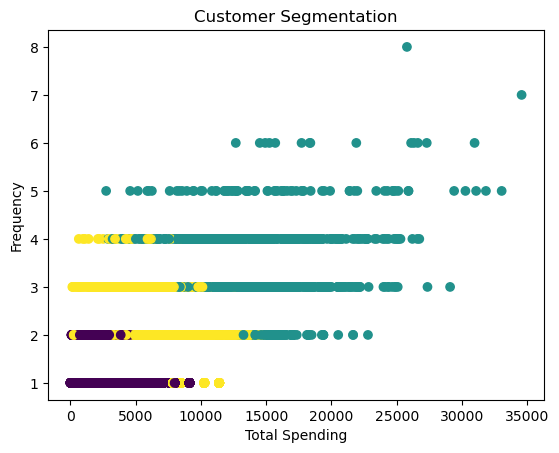

In [32]:
import matplotlib.pyplot as plt

plt.scatter(
    customer_df['total_spending'],
    customer_df['frequency'],
    c=customer_df['cluster']
)

plt.xlabel("Total Spending")
plt.ylabel("Frequency")
plt.title("Customer Segmentation")
plt.show()